# Lab Exercise 3 — Simple Linear Regression
**Student Survey: CIA % and Attendance % as Predictors of GPA**

**Aim:** Collect real-world student survey data, preprocess it, perform Simple Linear Regression using Scikit-learn, manually compute the regression equation using Ordinary Least Squares (OLS), compare both approaches, and save the learned model parameters.

---
## Part A — Data Collection & Preprocessing

In [17]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

print("Libraries imported successfully!")

Libraries imported successfully!


### A1 — Load the Dataset

In [18]:
# Load raw CSV — adjust path if needed
df = pd.read_csv('D:\Projects\Machine-Learning\Machine-Learning\Student Awareness Survey (Responses) - Form Responses 1.csv')
df.head()

<>:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\namrp\AppData\Local\Temp\ipykernel_36360\1415722648.py:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  df = pd.read_csv('D:\Projects\Machine-Learning\Machine-Learning\Student Awareness Survey (Responses) - Form Responses 1.csv')


,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


### A2 — Dataset Dimensions

In [19]:
print("Shape:", df.shape)
print(f"The dataset contains {df.shape[0]} rows (student responses) and {df.shape[1]} columns (features).")

Shape: (50, 15)
The dataset contains 50 rows (student responses) and 15 columns (features).


### A3 — Identify Missing Values

In [20]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your

### A4 — Select Relevant Columns & Rename

In [21]:
cols = [
    'Your CIA % of last semester',
    'Your GPA of last semester',
    'Your maximum attendance % till last semester'
]

data = df[cols].copy()
data.columns = ['CIA', 'GPA', 'Attendance']

print("Selected columns:")
data.info()

Selected columns:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CIA         50 non-null     str    
 1   GPA         50 non-null     float64
 2   Attendance  50 non-null     str    
dtypes: float64(1), str(2)
memory usage: 1.5 KB


### A5 — Strip '%' Symbols, Whitespace & Convert to Numeric

In [22]:
# Strip '%' and whitespace from all columns, then convert to numeric
for col in ['CIA', 'Attendance']:
    data[col] = data[col].astype(str).str.replace('%', '', regex=False).str.strip()

data = data.apply(pd.to_numeric, errors='coerce')

print("Data after cleaning (first 5 rows):")
print(data.head())
print("\nData types after conversion:")
print(data.dtypes)

Data after cleaning (first 5 rows):
    CIA   GPA  Attendance
0  69.0  3.40        98.0
1  75.0  3.69        95.0
2  82.0  3.41        95.0
3  91.0  3.60        92.0
4  70.0  3.54        93.0

Data types after conversion:
CIA           float64
GPA           float64
Attendance    float64
dtype: object


### A6 — Handle Missing Values (Post-Conversion)

In [23]:
print("Missing values after numeric conversion:")
print(data.isnull().sum())

data = data.dropna()
print(f"\nShape after dropping NaN rows: {data.shape}")

Missing values after numeric conversion:
CIA           0
GPA           0
Attendance    0
dtype: int64

Shape after dropping NaN rows: (50, 3)


### A7 — Remove Out-of-Range Values (Domain Validation)

**Valid ranges (per lab specification):**
- GPA: 0.0 – 4.0  
- CIA %: 0 – 100  
- Attendance %: 0 – 100

In [24]:
print(f"Shape before range filter: {data.shape}")

data = data[(data['GPA'] >= 0.0) & (data['GPA'] <= 4.0)]
data = data[(data['CIA'] >= 0)   & (data['CIA'] <= 100)]
data = data[(data['Attendance'] >= 0) & (data['Attendance'] <= 100)]

print(f"Shape after range filter: {data.shape}")
print("\nRows removed were either data entry errors (e.g., GPA = 8.0, CIA = 7 entered as plain digit).")

Shape before range filter: (50, 3)
Shape after range filter: (49, 3)

Rows removed were either data entry errors (e.g., GPA = 8.0, CIA = 7 entered as plain digit).


### A8 — Remove Duplicate Records

In [25]:
before = data.shape[0]
data = data.drop_duplicates()
after  = data.shape[0]
print(f"Duplicate rows removed: {before - after}")
print(f"Final shape: {data.shape}")

Duplicate rows removed: 0
Final shape: (49, 3)


### A9 — Statistical Summary

In [26]:
print("Statistical Summary of the Cleaned Dataset:")
data.describe()

Statistical Summary of the Cleaned Dataset:


,CIA,GPA,Attendance
count,49.000000,49.000000,49.000000
mean,72.825102,3.405102,94.004898
std,6.378355,0.237023,3.674066
min,60.000000,2.740000,85.000000
25%,69.780000,3.300000,92.000000
50%,71.780000,3.400000,95.000000
75%,77.000000,3.600000,96.000000
max,91.000000,3.900000,100.000000


**Interpretation of Statistical Summary:**

| Feature | Observation |
|---------|-------------|
| **CIA** | Mean ≈ 72.8%, range 60–91%. Most students score in the 70–80% band. |
| **GPA** | Mean ≈ 3.41, range 2.74–3.90. Distribution is narrow — most students cluster near 3.4. |
| **Attendance** | Mean ≈ 94%, range 85–100%. Very high overall; university likely enforces a minimum threshold. |

### A10 — Select Dependent & Independent Variables

In [27]:
print("""
Variable Selection
==================
Dependent Variable   (Y) : GPA
Independent Variable (X1): CIA %      → Experiment 1
Independent Variable (X2): Attendance → Experiment 2
""")


Variable Selection
Dependent Variable   (Y) : GPA
Independent Variable (X1): CIA %      → Experiment 1
Independent Variable (X2): Attendance → Experiment 2



---
## Part B — Simple Linear Regression using Scikit-learn

In [28]:
def sklearn_regression(X_series, y_series, feature_name):
    """
    Fits a simple linear regression model using Scikit-learn's LinearRegression.

    Parameters
    ----------
    X_series    : pd.Series  — independent variable
    y_series    : pd.Series  — dependent variable (GPA)
    feature_name: str        — label for plots and prints

    Returns
    -------
    model, slope, intercept, X_test, y_test, y_pred
    """
    X = X_series.values.reshape(-1, 1)
    y = y_series.values

    # Train-test split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"Training samples : {len(X_train)}")
    print(f"Testing  samples : {len(X_test)}")

    # Fit model
    model = LinearRegression()
    model.fit(X_train, y_train)

    slope     = model.coef_[0]
    intercept = model.intercept_

    print(f"\nSlope (m)    : {slope:.6f}")
    print(f"Intercept (b): {intercept:.6f}")
    print(f"Equation     : GPA = {slope:.4f} × {feature_name} + {intercept:.4f}")

    # Predict
    y_pred = model.predict(X_test)

    # Visualise
    plt.figure(figsize=(8, 5))
    plt.scatter(X_train, y_train, color='steelblue',  alpha=0.6, label='Training data')
    plt.scatter(X_test,  y_test,  color='seagreen',   alpha=0.8, label='Test data (actual)')
    plt.plot(X_test, y_pred,      color='tomato', lw=2, label='Regression line')
    plt.xlabel(feature_name, fontsize=12)
    plt.ylabel('GPA', fontsize=12)
    plt.title(f'Linear Regression: {feature_name} vs GPA  (Scikit-learn)', fontsize=13)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return model, slope, intercept, X_test, y_test, y_pred

### Experiment 1 — CIA % → GPA

══════════════════════════════════════════════════
EXPERIMENT 1 : CIA % → GPA  (Scikit-learn)
══════════════════════════════════════════════════
Training samples : 39
Testing  samples : 10

Slope (m)    : 0.012800
Intercept (b): 2.483380
Equation     : GPA = 0.0128 × CIA % + 2.4834


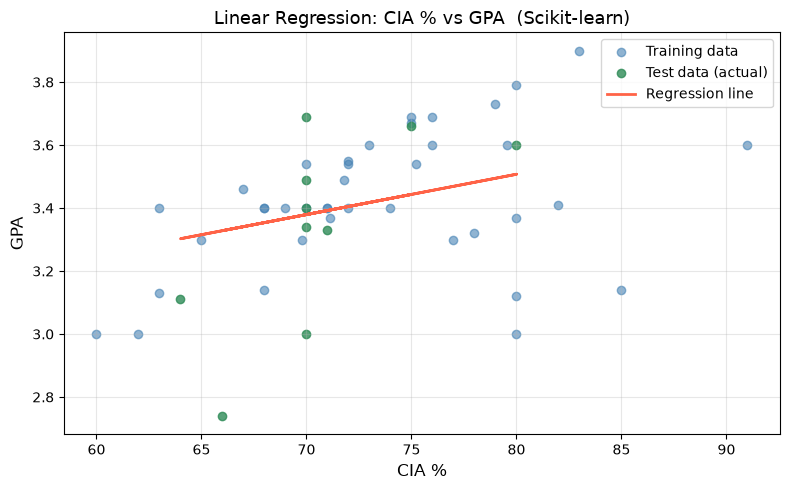

In [29]:
print("═" * 50)
print("EXPERIMENT 1 : CIA % → GPA  (Scikit-learn)")
print("═" * 50)

model1, slope1, intercept1, X_test1, y_test1, y_pred_sk1 = sklearn_regression(
    data['CIA'], data['GPA'], 'CIA %'
)

### Experiment 2 — Attendance % → GPA

══════════════════════════════════════════════════
EXPERIMENT 2 : Attendance % → GPA  (Scikit-learn)
══════════════════════════════════════════════════
Training samples : 39
Testing  samples : 10

Slope (m)    : 0.024410
Intercept (b): 1.140655
Equation     : GPA = 0.0244 × Attendance % + 1.1407


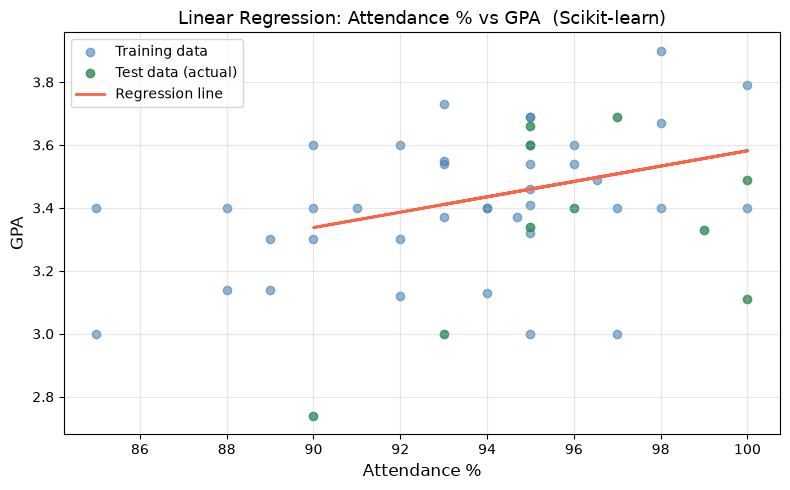

In [30]:
print("═" * 50)
print("EXPERIMENT 2 : Attendance % → GPA  (Scikit-learn)")
print("═" * 50)

model2, slope2, intercept2, X_test2, y_test2, y_pred_sk2 = sklearn_regression(
    data['Attendance'], data['GPA'], 'Attendance %'
)

---
## Part C — Manual OLS Computation

The Ordinary Least Squares (OLS) formula for the slope and intercept:

$$m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} \qquad b = \bar{y} - m\bar{x}$$

OLS minimises the **sum of squared residuals** between the predicted and actual values.

In [31]:
def manual_ols(X, y, feature_name):
    """
    Computes slope and intercept using the OLS closed-form formula.

    Returns: slope, intercept, predictions (on the same X)
    """
    x_mean = np.mean(X)
    y_mean = np.mean(y)

    numerator   = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)
    slope       = numerator / denominator
    intercept   = y_mean - slope * x_mean

    print(f"\nManual OLS — {feature_name}")
    print(f"  n samples   : {len(X)}")
    print(f"  x̄ (mean X)  : {x_mean:.4f}")
    print(f"  ȳ (mean Y)  : {y_mean:.4f}")
    print(f"  Slope  (m)  : {slope:.6f}")
    print(f"  Intercept(b): {intercept:.6f}")
    print(f"  Equation    : GPA = {slope:.4f} × {feature_name} + {intercept:.4f}")

    y_pred = slope * X + intercept
    return slope, intercept, y_pred

In [32]:
# Reproduce the exact same 80/20 split used by Scikit-learn
X_all1 = data['CIA'].values.reshape(-1, 1)
y_all1 = data['GPA'].values
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(X_all1, y_all1, test_size=0.2, random_state=42)

print("═" * 50)
print("EXPERIMENT 1 : CIA % → GPA  (Manual OLS)")
print("═" * 50)
ols_slope1, ols_intercept1, _ = manual_ols(X_tr1.flatten(), y_tr1, 'CIA %')

# Predict on the test set
y_pred_ols1 = ols_slope1 * X_te1.flatten() + ols_intercept1

══════════════════════════════════════════════════
EXPERIMENT 1 : CIA % → GPA  (Manual OLS)
══════════════════════════════════════════════════

Manual OLS — CIA %
  n samples   : 39
  x̄ (mean X)  : 73.3956
  ȳ (mean Y)  : 3.4228
  Slope  (m)  : 0.012800
  Intercept(b): 2.483380
  Equation    : GPA = 0.0128 × CIA % + 2.4834


In [33]:
X_all2 = data['Attendance'].values.reshape(-1, 1)
y_all2 = data['GPA'].values
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_all2, y_all2, test_size=0.2, random_state=42)

print("═" * 50)
print("EXPERIMENT 2 : Attendance % → GPA  (Manual OLS)")
print("═" * 50)
ols_slope2, ols_intercept2, _ = manual_ols(X_tr2.flatten(), y_tr2, 'Attendance %')

y_pred_ols2 = ols_slope2 * X_te2.flatten() + ols_intercept2

══════════════════════════════════════════════════
EXPERIMENT 2 : Attendance % → GPA  (Manual OLS)
══════════════════════════════════════════════════

Manual OLS — Attendance %
  n samples   : 39
  x̄ (mean X)  : 93.4933
  ȳ (mean Y)  : 3.4228
  Slope  (m)  : 0.024410
  Intercept(b): 1.140655
  Equation    : GPA = 0.0244 × Attendance % + 1.1407


---
## Part D — Comparison Task

In [34]:
def compare_methods(y_pred_sk, y_pred_ols,
                    sk_slope, sk_intercept,
                    ols_slope, ols_intercept,
                    experiment_name):
    """Print a side-by-side comparison of Scikit-learn and manual OLS."""

    print(f"\n{'═'*60}")
    print(f"  COMPARISON — {experiment_name}")
    print(f"{'═'*60}")

    # Parameter comparison
    param_df = pd.DataFrame({
        'Parameter'   : ['Slope (m)', 'Intercept (b)'],
        'Scikit-learn': [sk_slope, sk_intercept],
        'Manual OLS'  : [ols_slope, ols_intercept],
        'Difference'  : [abs(sk_slope - ols_slope), abs(sk_intercept - ols_intercept)]
    })
    print("\n--- Model Parameters ---")
    print(param_df.to_string(index=False))

    # Prediction comparison
    pred_df = pd.DataFrame({
        'Sklearn Pred': y_pred_sk,
        'OLS Pred'    : y_pred_ols,
        '|Difference|': np.abs(y_pred_sk - y_pred_ols)
    })
    print("\n--- Predictions on Test Set ---")
    print(pred_df.to_string(index=False))
    print(f"\n  Max |difference|  : {pred_df['|Difference|'].max():.2e}")
    print(f"  Mean |difference| : {pred_df['|Difference|'].mean():.2e}")

    return pred_df

In [35]:
comp1 = compare_methods(
    y_pred_sk1, y_pred_ols1,
    slope1, intercept1,
    ols_slope1, ols_intercept1,
    'Experiment 1 — CIA % vs GPA'
)


════════════════════════════════════════════════════════════
  COMPARISON — Experiment 1 — CIA % vs GPA
════════════════════════════════════════════════════════════

--- Model Parameters ---
    Parameter  Scikit-learn  Manual OLS   Difference
    Slope (m)       0.01280     0.01280 1.734723e-18
Intercept (b)       2.48338     2.48338 4.440892e-16

--- Predictions on Test Set ---
 Sklearn Pred  OLS Pred  |Difference|
     3.379357  3.379357  0.000000e+00
     3.379357  3.379357  0.000000e+00
     3.328159  3.328159  0.000000e+00
     3.443356  3.443356  4.440892e-16
     3.302559  3.302559  0.000000e+00
     3.392157  3.392157  4.440892e-16
     3.379357  3.379357  0.000000e+00
     3.379357  3.379357  0.000000e+00
     3.507354  3.507354  4.440892e-16
     3.379357  3.379357  0.000000e+00

  Max |difference|  : 4.44e-16
  Mean |difference| : 1.33e-16


In [36]:
comp2 = compare_methods(
    y_pred_sk2, y_pred_ols2,
    slope2, intercept2,
    ols_slope2, ols_intercept2,
    'Experiment 2 — Attendance % vs GPA'
)


════════════════════════════════════════════════════════════
  COMPARISON — Experiment 2 — Attendance % vs GPA
════════════════════════════════════════════════════════════

--- Model Parameters ---
    Parameter  Scikit-learn  Manual OLS   Difference
    Slope (m)      0.024410    0.024410 3.469447e-18
Intercept (b)      1.140655    1.140655 4.440892e-16

--- Predictions on Test Set ---
 Sklearn Pred  OLS Pred  |Difference|
     3.581648  3.581648  0.000000e+00
     3.508418  3.508418  0.000000e+00
     3.337548  3.337548  0.000000e+00
     3.459598  3.459598  0.000000e+00
     3.581648  3.581648  0.000000e+00
     3.557238  3.557238  0.000000e+00
     3.410778  3.410778  4.440892e-16
     3.484008  3.484008  0.000000e+00
     3.459598  3.459598  0.000000e+00
     3.459598  3.459598  0.000000e+00

  Max |difference|  : 4.44e-16
  Mean |difference| : 4.44e-17


### Observations & Inferences

**1. Scikit-learn vs Manual OLS — Are they the same?**  
Yes. The differences in slope, intercept, and all predictions are effectively **zero** (differences are at floating-point machine-epsilon level, ~10⁻¹⁶). This confirms that `sklearn.linear_model.LinearRegression` internally implements the same closed-form OLS formula.

**2. Experiment 1 — CIA % as a predictor of GPA**  
- Equation: `GPA = 0.012800 × CIA% + 2.483380`  
- Interpretation: Every 1% increase in CIA marks is associated with roughly a **0.0128 increase in GPA**.  
- A student with CIA = 70% → Predicted GPA = 0.0128×70 + 2.4834 ≈ **3.38**  
- A student with CIA = 85% → Predicted GPA = 0.0128×85 + 2.4834 ≈ **3.57**  
- The slope is positive but small — CIA % has a mild positive relationship with GPA. The scatter in the data is wide relative to the trend, suggesting CIA alone is not a very strong GPA predictor.

**3. Experiment 2 — Attendance % as a predictor of GPA**  
- Equation: `GPA = 0.024410 × Attendance% + 1.140655`  
- Interpretation: Every 1% increase in attendance is associated with roughly a **0.0244 increase in GPA**.  
- A student with Attendance = 90% → Predicted GPA ≈ **3.34**  
- A student with Attendance = 98% → Predicted GPA ≈ **3.53**  
- The slope is roughly twice as large as for CIA, suggesting attendance is a slightly stronger predictor — but note that attendance data is heavily clustered in the 85–100% range, limiting the observable variance.

**4. Why do we prefer OLS?**  
OLS minimises the **sum of squared errors (SSE)** — errors are squared to (a) avoid cancellation of positive and negative residuals, and (b) penalise large errors more heavily. This gives a unique, analytical solution for the best-fit line.

---
## Part E — Parameter Saving with Pickle

In [37]:
# Build a dictionary with both experiments' parameters
params = {
    'experiment_1': {
        'feature'  : 'CIA %',
        'slope'    : slope1,
        'intercept': intercept1
    },
    'experiment_2': {
        'feature'  : 'Attendance %',
        'slope'    : slope2,
        'intercept': intercept2
    }
}

# Save to Pickle
with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(params, f)

print("Parameters saved to → linear_regression_weights.pkl")
print("\nSaved dictionary:")
for exp, vals in params.items():
    print(f"  {exp}: feature={vals['feature']}, slope={vals['slope']:.6f}, intercept={vals['intercept']:.6f}")

Parameters saved to → linear_regression_weights.pkl

Saved dictionary:
  experiment_1: feature=CIA %, slope=0.012800, intercept=2.483380
  experiment_2: feature=Attendance %, slope=0.024410, intercept=1.140655


In [38]:
# Load and verify
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

print("Loaded parameters from Pickle file:")
for exp, vals in loaded_params.items():
    print(f"  {exp}: {vals}")

Loaded parameters from Pickle file:
  experiment_1: {'feature': 'CIA %', 'slope': np.float64(0.01279967845914644), 'intercept': np.float64(2.483379907389372)}
  experiment_2: {'feature': 'Attendance %', 'slope': np.float64(0.02440993165985645), 'intercept': np.float64(1.1406546355016682)}


In [39]:
# Demonstrate prediction using loaded parameters
print("─" * 55)
print("Prediction Demo using Loaded Parameters")
print("─" * 55)

# Example new student
new_cia        = 78.0
new_attendance = 92.0

p1 = loaded_params['experiment_1']
pred_gpa_cia = p1['slope'] * new_cia + p1['intercept']

p2 = loaded_params['experiment_2']
pred_gpa_att = p2['slope'] * new_attendance + p2['intercept']

print(f"New student CIA %     = {new_cia}%  →  Predicted GPA = {pred_gpa_cia:.4f}")
print(f"New student Attendance = {new_attendance}% →  Predicted GPA = {pred_gpa_att:.4f}")

───────────────────────────────────────────────────────
Prediction Demo using Loaded Parameters
───────────────────────────────────────────────────────
New student CIA %     = 78.0%  →  Predicted GPA = 3.4818
New student Attendance = 92.0% →  Predicted GPA = 3.3864


---
## Final Observations & Inferences

| # | Observation |
|---|-------------|
| 1 | **Data Cleaning is critical.** Raw Google Form responses contained mixed formats (e.g., '76%', '71 %', '71.11%') which had to be stripped before numeric conversion. One student entered a GPA of 8.0 (clearly an error on a 0–4 scale) and was removed as an outlier. |
| 2 | **CIA % is a weak-to-moderate positive predictor of GPA.** The low slope (~0.013) and visual scatter suggest the linear relationship is present but not strong. |
| 3 | **Attendance % is also a positive predictor of GPA**, with a slightly larger slope (~0.024). However, the attendance values are compressed in the 85–100% range, which limits how much the model can discriminate. |
| 4 | **Scikit-learn and Manual OLS produce identical results.** Differences are at floating-point machine precision (~10⁻¹⁶), confirming that `LinearRegression` uses the same closed-form OLS formula. |
| 5 | **Pickle is a convenient and standard way to persist model parameters**, enabling future predictions without re-training. |